# Inläning av Torchcam och analys

In [248]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask
import json
import torch

Här hämtar vi som vanligt in de bibliotek som vi behöver för att fullfölja uppgiften

In [249]:
weights = get_model_weights ('resnet18').DEFAULT
model = get_model('resnet18', weights=weights).eval()

preprocess  = weights.transforms()
img = decode_image ("C:/Users/matti/Downloads/Atlas_moth.webp")

I sektionen över så väljer vi att anväda de redan angivna parrametrarna som ResNet18 redan har som standard

In [250]:
input_tensor= preprocess (img)

with LayerCAM(model) as cam_extractor:
    out = model (input_tensor.unsqueeze(0))
    activation_map = cam_extractor (out.squeeze(0).argmax().item(), out)


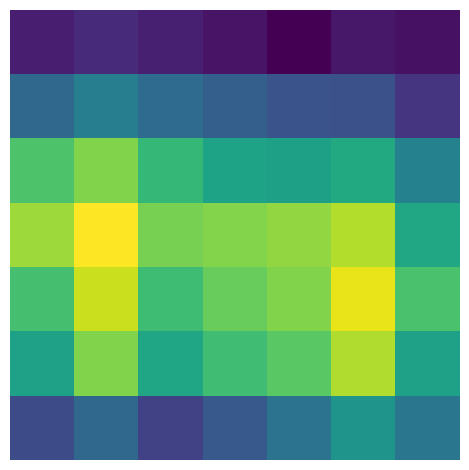

In [251]:
plt.imshow(activation_map[0].squeeze(0).numpy())
plt.axis('off')
plt.tight_layout()
plt.show()


Vi kan se att programmet fokuserar på två punkter, en på nästan vardera del av bilden. Men vad är det som detta ger oss? Ett enkelt sett att se detta är om vi börjar med att lägga den ena bilden ovanpå den andra.

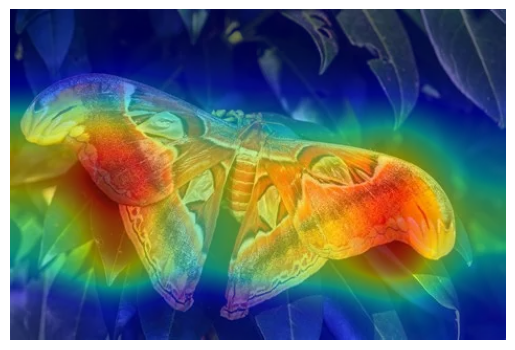

In [252]:
result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'),alpha=0.5)
plt.imshow(result)
plt.axis('off')
plt.tight_layout
plt.show()

Här börjar vi att lägga vår analysbild ovanpå vår orginalbild. vilket get oss en klarare bid av vad vi tittar på men även vad det är som programmet fokuserar på. Vi kan se i den bild vi har att programmet fokuserar på malens vingar. Vilket i de flesta fall när det kommer till malar och fjärilar är ett bra ställe att titta på.


In [253]:
def predict_class (output_tensor: torch.Tensor, class_index_path: str) -> dict:
    with open (class_index_path, 'r') as f:
        class_index = json.load(f)
    
    probs = output_tensor.squeeze()
    if probs.ndim!=1 or probs.shape[0] !=1000:
        raise ValueError(f'The shape isnt of a value of 1000, instead its {tuple(output_tensor.shape)}')
    
    top_idx = int(probs.argmax())
    synset_id, class_name = class_index[str(top_idx)]
    return{'class_index' : top_idx,
        'class_id': synset_id,
        'class_name': class_name,
        'confidence': float(probs[top_idx]),
           }

Här låter vi programmet leta i en databas efter vad den anser vara mest likt bilden vi lägger in.

In [254]:
model.eval()
batch = preprocess (img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)

In [255]:
predict_class (prediction.detach(),"C:/Users/matti/Downloads/imagenet_class_index.json")

{'class_index': 47,
 'class_id': 'n01694178',
 'class_name': 'African_chameleon',
 'confidence': 0.20882228016853333}

In [264]:
def pred_top5 (output_tensor: torch.Tensor, class_index_path: str) -> dict:
    with open (class_index_path, 'r') as f:
        class_index = json.load(f)
    prob = torch.softmax(output_tensor.squeeze(),dim=0)
    top5_prob, top5_ind = torch.topk(prob, 5)


    for i in range (5):
        ind = str(top5_ind[i].item())
        probability = top5_prob[i].item() * 100
        class_name = class_index[ind][1]
        print(f"{i+1}: {class_name} ({probability:.2f}%)")
pred_top5 (prediction.detach(),"C:/Users/matti/Downloads/imagenet_class_index.json")
        

1: African_chameleon (0.12%)
2: cicada (0.12%)
3: American_lobster (0.11%)
4: stinkhorn (0.11%)
5: triceratops (0.11%)


Den skriver att det skall vara en Afrikansk kamiljont, men med bara en 20% säkerhet. Detta ger oss att den inte är säker alls och att en chansning har bättre statestik. Vi kan med detta svar utgå ifrån att Atlasspinnare inte finns i filen.

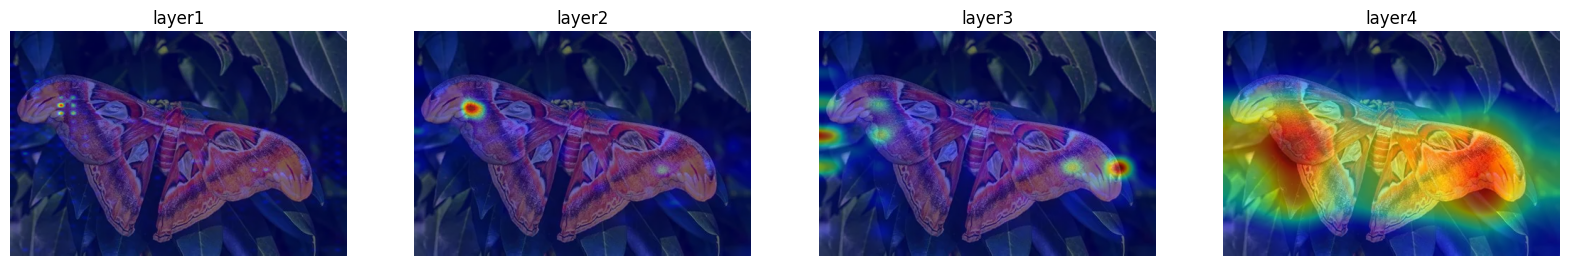

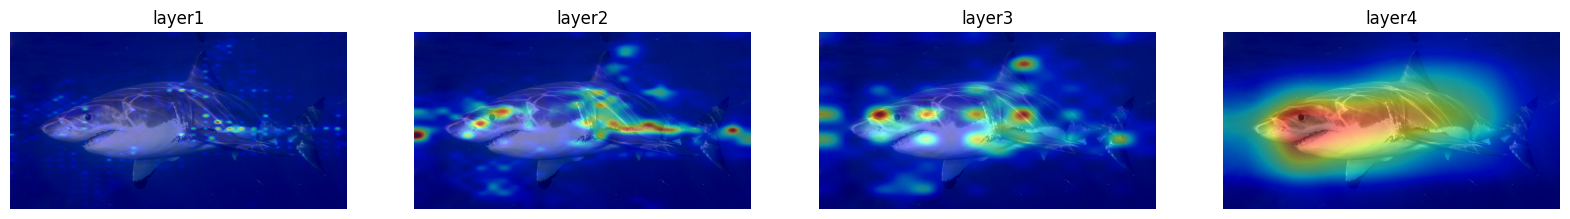

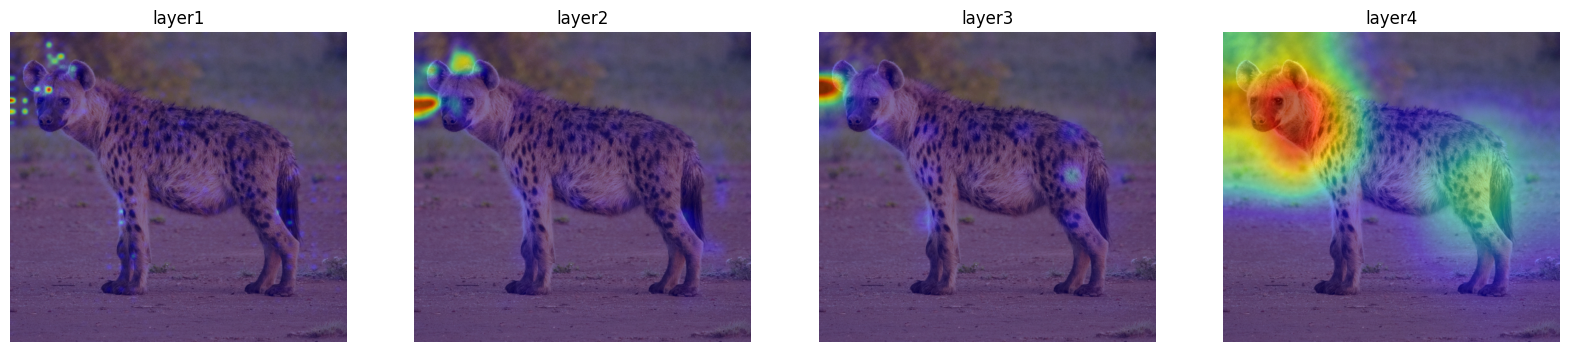

In [258]:
pic=[]
Both = ["C:/Users/matti/Downloads/Atlas_moth.webp",
        "C:/Users/matti/Downloads/Shark.jpg",
        "C:/Users/matti/Downloads/Hyena.webp"]
for photo in Both:
    photo=decode_image(photo)
    pic.append(photo)

    layers = ['layer1', 'layer2', 'layer3', 'layer4']
    with LayerCAM (model, target_layer=layers) as cam_extractor:
        out= model(preprocess(photo).unsqueeze(0))
        activation_map = cam_extractor(out.squeeze(0).argmax(0).item(), out)
    fig, axes= plt.subplots(1, len(layers),figsize=(20,10))

    for i, (act_map, layer_name) in enumerate(zip(activation_map, layers)):
        result = overlay_mask (to_pil_image(photo), to_pil_image (act_map.squeeze(0),mode='F'), alpha=0.5)
        axes[i].imshow(result)
        axes[i].set_title((layer_name))
        axes[i].axis('off')







Vi kan se här väldigt klart hur den först söker efter distinkta punkter i båda bilderna. på Atlasspinnare så börjar den tentativt i högra vingen för att sedan fokusera och korrilera den med vänster vinge. för att i slutet lägga störst fokus där. Det är även så vi människor ser skillnad på dessa insekter. Genom deras markeringar.
Vithajen däremot så börjar den med att lägga störst fokus på dess vänstra fena för att i senare ittrationer låta den växa till at den söker av, i stort sett, hela. Men den lägger störst fokus på hajens huvud.
Så vi kan se på bäge bilderna hur den bygger upp en outline och skapar genom detta en starkare bild lager för lager tills att den har byggt upp värden och med det en klar bild att jämföra med.
Något intressant som vi ser i vår bild av hyenan så imellan lager två och tre så släpper vi fokuset lite från huvudet och ser mer till dess bakben för att i fjädre forsätta med att fokusera på dess ansikte men håller kvar att baken är av intresse. Detta får mig att fundera på vad som liknar hyenan så att den ser till dess bakben.

In [265]:
model.eval()
for x in Both:
    Image_fokus = decode_image (x)
    sack = preprocess(Image_fokus).unsqueeze(0)
    what_both = model(sack).squeeze(0).softmax(0)
    text= pred_top5 (what_both.detach(),"C:/Users/matti/Downloads/imagenet_class_index.json")
    print (text)


1: African_chameleon (0.12%)
2: cicada (0.12%)
3: American_lobster (0.11%)
4: stinkhorn (0.11%)
5: triceratops (0.11%)
None
1: great_white_shark (0.26%)
2: tiger_shark (0.10%)
3: hammerhead (0.10%)
4: sturgeon (0.10%)
5: coho (0.10%)
None
1: hyena (0.27%)
2: cheetah (0.10%)
3: African_hunting_dog (0.10%)
4: lynx (0.10%)
5: leopard (0.10%)
None


Här kan vi se att programmet hittade vithajen i sitt sortument, och detta med en 97.6% säkerhet, så vi kan nu se att den kan röna ut likheter mellan bilden vi använde och de som den har i sitt index. Vi kan även se hur dess säkerhet för hyena